# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [2]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [3]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Nguyen Hoang Khai Minh"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600159"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%);
                color: white; padding: 15px; border-radius: 10px;
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} |
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [4]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://bow-become-tail-food.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [5]:
display_student_header()

# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 5 nodes

🖥️  node-00:
   GPU 0 [T4] 🔴 Util: 86.7% | Mem: 10.6/16.0GB | Power: 49W | Temp: 68°C
   GPU 1 [T4] 🔴 Util: 74.2% | Mem: 14.2/16.0GB | Power: 51W | Temp: 81°C

🖥️  node-01:
   GPU 0 [A100] 🔴 Util: 84.3% | Mem: 71.4/80.0GB | Power: 197W | Temp: 59°C
   GPU 1 [A100] 🔴 Util: 71.3% | Mem: 67.7/80.0GB | Power: 284W | Temp: 70°C

🖥️  node-02:
   GPU 0 [V100] 🔴 Util: 72.9% | Mem: 17.4/32.0GB | Power: 235W | Temp: 78°C
   GPU 1 [V100] 🟢 Util: 8.6% | Mem: 1.6/32.0GB | Power: 47W | Temp: 36°C

🖥️  node-03:
   GPU 0 [T4] 🟢 Util: 5.8% | Mem: 1.6/16.0GB | Power: 33W | Temp: 34°C
   GPU 1 [T4] 🟢 Util: 4.0% | Mem: 1.0/16.0GB | Power: 45W | Temp: 39°C

🖥️  node-04:
   GPU 0 [T4] 🟢 Util: 0.0% | Mem: 0.5/16.0GB | Power: 20W | Temp: 30°C
   GPU 1 [T4] 🟢 Util: 0.0% | Mem: 0.5/16.0GB | Power: 20W | Temp: 30°C


In [6]:
display_student_header()

# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          10
Busy GPUs:           5
Idle GPUs:           5
Avg Utilization:     40.8%
Memory Used:         186.6 GB
Memory Capacity:     320.0 GB
Total Power Draw:    980 W
Node Count:          5


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [7]:
display_student_header()

# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-03', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-02', 'gpu_id': 1}]
   inference-api-003: running → [{'node_id': 'node-03', 'gpu_id': 1}]
   train-llm-004: running → [{'node_id': 'node-04', 'gpu_id': 0}, {'node_id': 'node-04', 'gpu_id': 1}]

📊 Updated metrics:
   Busy GPUs: 10/10 | Utilization: 76.0%


In [8]:
display_student_header()

# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $2.5589
   Total Savings:  $2.7078
   Budget Used:    2.6%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [9]:
display_student_header()

# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2044     41.6    % low
A100       $3.67       $2.2766     38.0    % high
V100       $2.48       $1.7844     28.1    % medium


In [10]:
display_student_header()

# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [11]:
display_student_header()

# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 2
   Still active: 4

   ⚠️  Preempted:
      - opt-spot-0 (ran for 113s, 30s warning)
      - opt-spot-2 (ran for 113s, 60s warning)

💰 Spot Savings Report:
   Spot cost:        $0.0035
   On-demand equiv:  $0.0116
   Total saved:      $0.0081 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [12]:
display_student_header()

# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 70.0
   scale_down_threshold: 25.0
   cooldown_seconds: 30
   max_nodes: 10
   min_nodes: 2
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [13]:
display_student_header()

# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ⬆️ Action: SCALE_UP
   Reason: Utilization 76.0% > threshold 70.0%
   Current utilization: 76.0%
   Nodes: 5 → 6

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 63.4% | Nodes: 6→6
   Cycle 2: no_action    | Util: 63.4% | Nodes: 6→6
   Cycle 3: no_action    | Util: 63.4% | Nodes: 6→6
   Cycle 4: no_action    | Util: 63.4% | Nodes: 6→6
   Cycle 5: no_action    | Util: 63.4% | Nodes: 6→6


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [14]:
display_student_header()

# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 2: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 3: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 4: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 5: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%


In [15]:
display_student_header()

# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          12.1%
   Total Idle Cost:        $0.046996
   Total Cost:             $0.401944
   Potential Monthly Save:  $1218.14
   Severity:               LOW


In [16]:
display_student_header()

# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [17]:
display_student_header()

# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 12 GPUs across 6 nodes
   Utilization: 63.4% | Busy: 10 | Idle: 2

💰 BILLING: $2.5589 / $100.00 budget
   Alert: OK | Savings: $2.7078

🎯 SPOT: Saved $0.0260 (70.0%)

🗑️  WASTE: 12.1% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

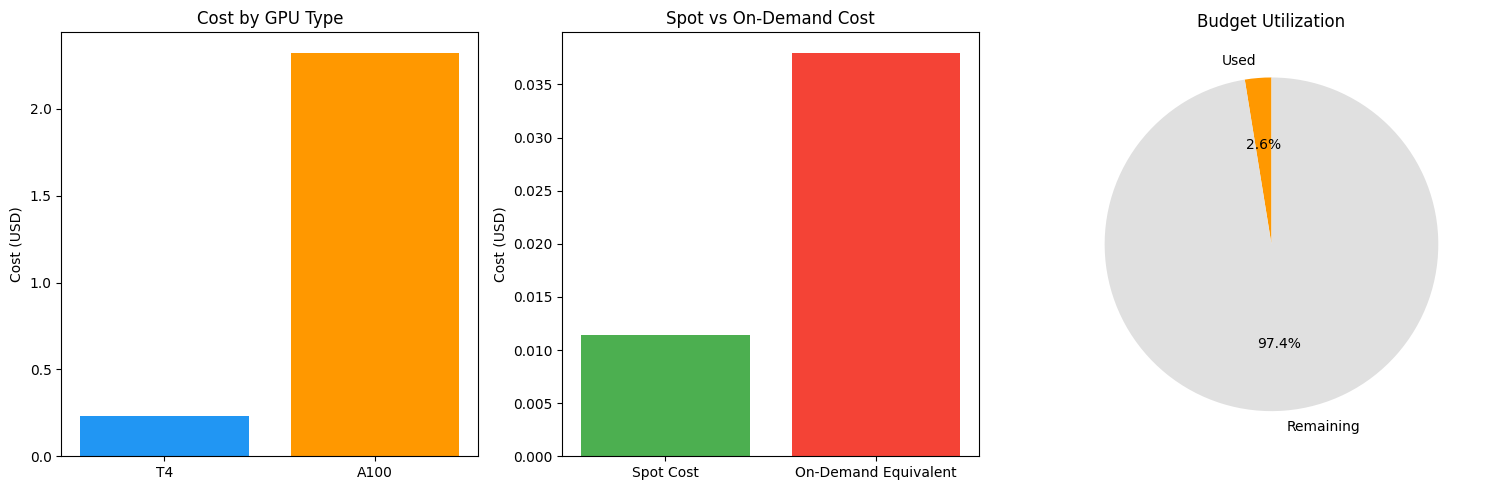

📊 Chart saved as finops_cost_breakdown.png


In [18]:
display_student_header()

# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


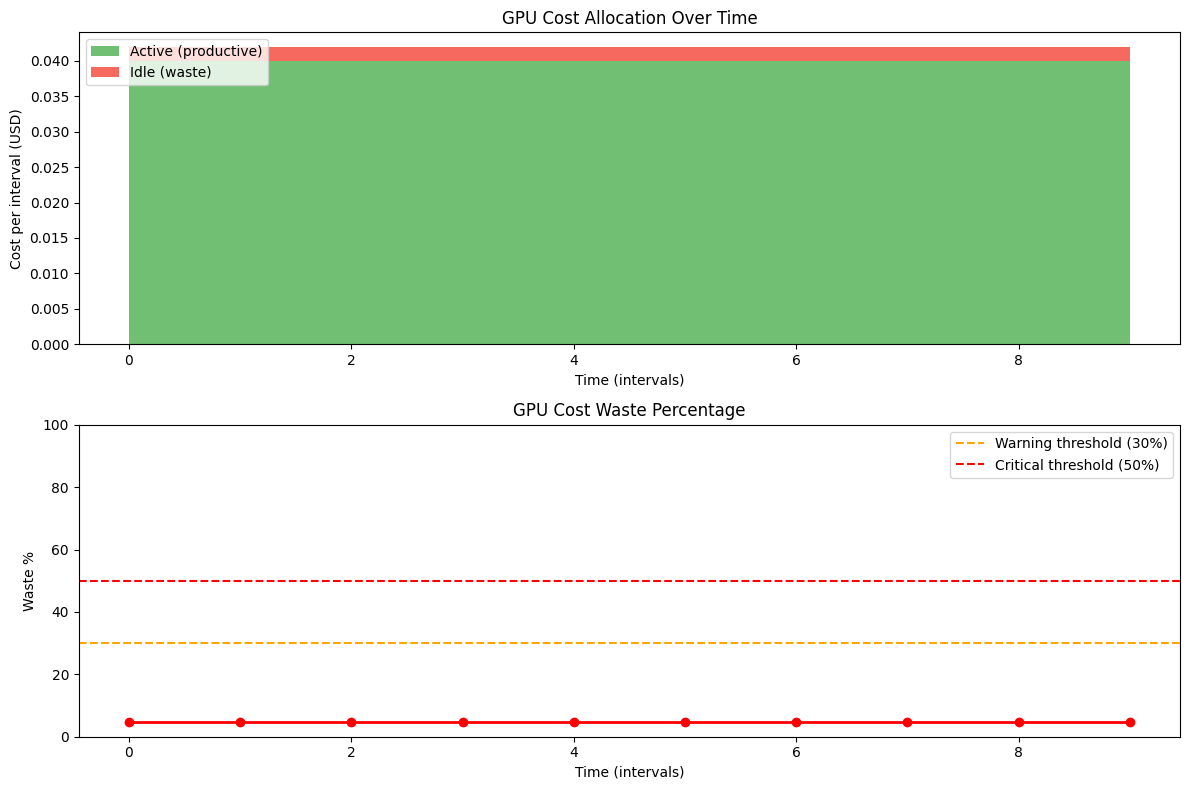

In [19]:
display_student_header()

# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [20]:
display_student_header()

# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 12 | Util: 63.4% | Idle: 2

2️⃣  Submitting heavy workloads...
   After load: Util: 76.9% | Busy: 12/12

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 76.9% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.043889
   Waste: 4.4%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0325 (70.0%)

7️⃣  Final billing:
   Total spend: $2.7280
   Total saved: $2.8302
   Budget: 2.7% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [21]:
display_student_header()

# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [22]:
display_student_header()

# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 10.0W
   Temp: 39C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 9.956
   temp_c: 39.0

   Method: pynvml

Ready for training.


In [23]:
display_student_header()

# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:14<00:00, 11.8MB/s]


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [24]:
display_student_header()

# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 2.0526 | Acc: 25.6% | Time: 44.9s | Samples: 40
   Epoch 2/3 | Loss: 1.4341 | Acc: 47.2% | Time: 40.7s | Samples: 40
   Epoch 3/3 | Loss: 1.1212 | Acc: 59.7% | Time: 44.4s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      129.9s
   Peak memory:     0.82 GB
   Avg GPU util:    89.4%
   Avg power:       67.1W
   Avg temperature: 65.1C
   Max GPU util:    98.0%
   Estimated cost:  $0.012632


In [25]:
display_student_header()

# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_1458/4283856052.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_1458/4283856052.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.9391 | Acc: 29.6% | Time: 25.5s | Samples: 40
   Epoch 2/3 | Loss: 1.4090 | Acc: 48.1% | Time: 25.4s | Samples: 40
   Epoch 3/3 | Loss: 1.1395 | Acc: 58.7% | Time: 25.4s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      76.3s
   Peak memory:     0.60 GB
   Avg GPU util:    65.2%
   Avg power:       64.7W
   Avg temperature: 76.8C
   Max GPU util:    85.0%
   Estimated cost:  $0.007416


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                129.9           76.3            1.70x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.012632       $0.007416       $0.005216 saved
Cost Saving %             ---             ---             41.3%
Avg GPU Util %            89.4            65.2           
Avg Power (W)             67.1            64.7           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$4.93 -> SAVE $3.47
   1 week training: FP32=$58.80 vs AMP=$34.52 -> SAVE $24.28
   1 month training: FP32=$252.00 vs AMP=$147.95 -> SAVE $104.05


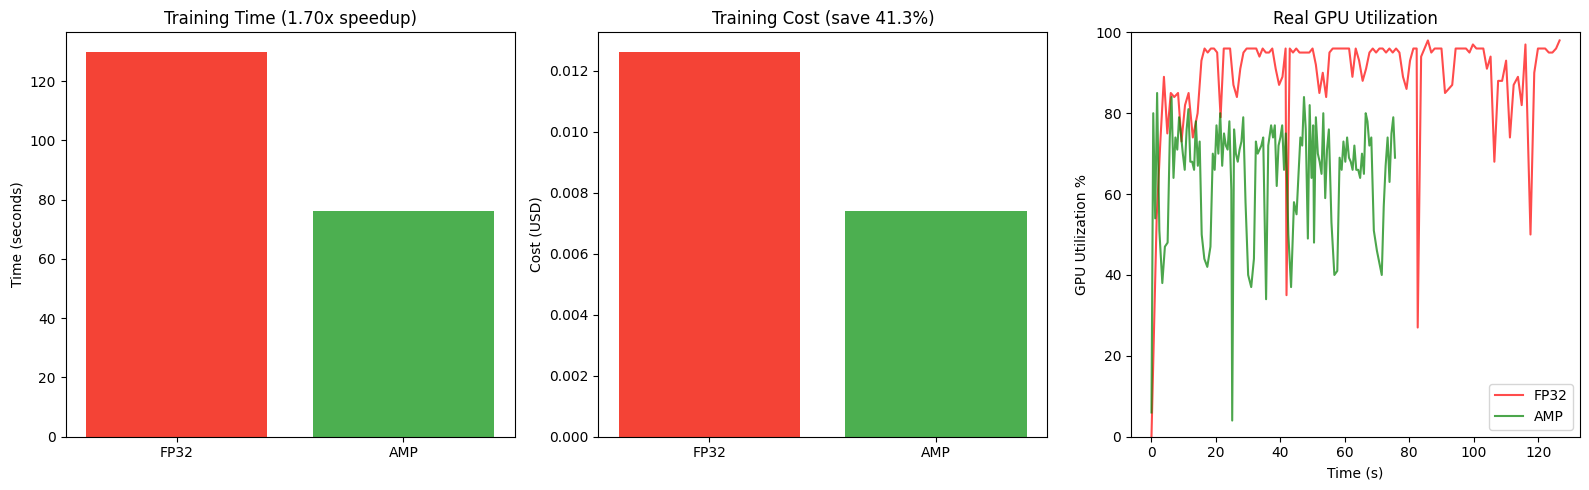

In [26]:
display_student_header()

# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
display_student_header()

# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.012600 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.002200 | Saved: $0.005200

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.014800
   Total Savings:   $0.005200
   Workloads:       2

   Cost snapshot taken: waste=20.1%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $2.7280
   Total Savings:        $2.8302
   Budget Utilization:   2.7%
   Alert:                OK


Real GPU Telemetry During Training


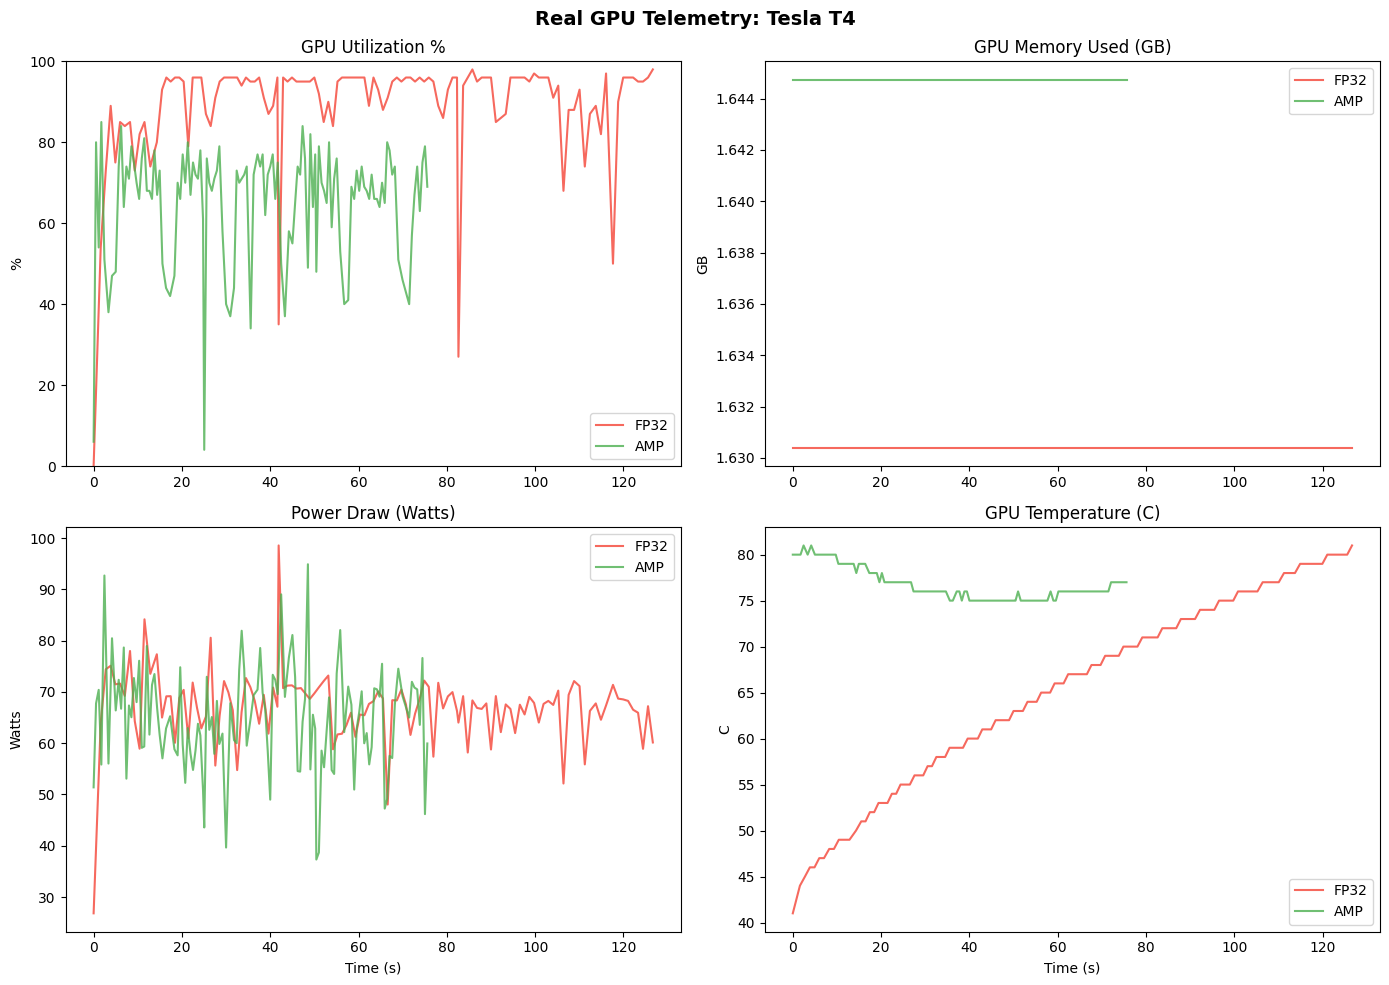

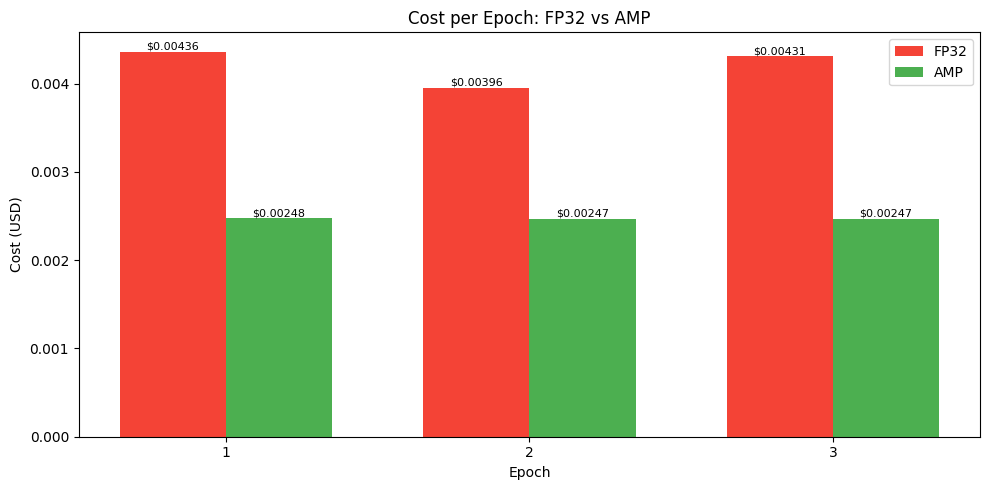


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [28]:
display_student_header()

# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

In [36]:
display_student_header()

# Cell 27: Multi-GPU Cost Analysis
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

# TODO: Implement function to analyze costs for different GPU counts
# Hint: Consider scaling efficiency - more GPUs doesn't always mean linear speedup

def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """
    TODO: Implement this function to analyze multi-GPU training costs

    Parameters:
        base_time_hours (float): Single-GPU training time in hours
        gpu_type (str): GPU type (T4, A100, etc.)
        gpu_counts (list): List of GPU counts to analyze (e.g., [1, 2, 4, 8])
        scaling_factors (dict, optional): Scaling efficiency factors {gpu_count: efficiency}
                                         If None, assume realistic sub-linear scaling

    Returns:
        dict: Analysis with costs, times, and efficiency metrics
    """
    # TODO: Implement the function
    # - Get base price from GPU_PRICING
    # - If no scaling_factors provided, create realistic ones (e.g., 2 GPUs = 1.8x speedup, not 2.0x)
    # - Calculate time for each GPU count (base_time / scaling_factor)
    # - Calculate cost for each (time * price * gpu_count)
    # - Calculate cost per performance unit
    # - Return analysis dictionary
    if gpu_type not in GPU_PRICING:
        raise ValueError(f"Unknown GPU type: {gpu_type}")

    base_price = GPU_PRICING[gpu_type]

    # Realistic scaling efficiency
    if scaling_factors is None:
        scaling_factors = {
            1: 1.0,
            2: 1.8,
            4: 3.2,
            8: 5.8
        }

    results = []

    for gpu_count in gpu_counts:

        speedup = scaling_factors.get(gpu_count, gpu_count * 0.7) # If not in scaling factors, fallback gpu counts * 0.7

        # Training time decreases with speedup
        training_time = base_time_hours / speedup

        # Total training cost
        total_cost = training_time * base_price * gpu_count

        # Parallel efficiency
        efficiency = speedup / gpu_count

        results.append({
            "gpu_count": gpu_count,
            "speedup": round(speedup, 2),
            "efficiency": round(efficiency * 100, 2),
            "training_time": round(training_time, 2),
            "total_cost": round(total_cost, 2)
        })

    return results


# Test data
base_training_time = 2.0  # hours for single GPU
test_gpu_counts = [1, 2, 4, 8]

# TODO: Call the function and display results
# Hint: Create a table showing GPU count, time, cost, cost-performance ratio

print("\n📊 TODO: Implement analyze_multi_gpu_cost function")
print("   Expected output: Table comparing 1, 2, 4, 8 GPU configurations")
print("   Show: Time reduction, Total cost, Cost per unit performance")
print("   Identify: Optimal GPU count for cost efficiency")

# Run analysis
results = analyze_multi_gpu_cost(
    base_time_hours=base_training_time,
    gpu_type="A100",
    gpu_counts=test_gpu_counts
)

# Display results
print(f"\nGPU Type: A100")
print(f"Base Training Time: {base_training_time} hours")

print("\n📊 Multi-GPU Cost Comparison")
print("-" * 75)

header = (
    f"{'GPUs':<8}"
    f"{'Speedup':<12}"
    f"{'Efficiency':<15}"
    f"{'Time(h)':<12}"
    f"{'Cost($)':<12}"
)

print(header)
print("-" * 75)

best_option = min(results, key=lambda x: x["total_cost"])

for row in results:

    print(
        f"{row['gpu_count']:<8}"
        f"{row['speedup']:<12}"
        f"{str(row['efficiency']) + '%':<15}"
        f"{row['training_time']:<12}"
        f"{row['total_cost']:<12}"
    )

print("-" * 75)

EXERCISE 8.5.1: Multi-GPU Cost Analysis

📊 TODO: Implement analyze_multi_gpu_cost function
   Expected output: Table comparing 1, 2, 4, 8 GPU configurations
   Show: Time reduction, Total cost, Cost per unit performance
   Identify: Optimal GPU count for cost efficiency

GPU Type: A100
Base Training Time: 2.0 hours

📊 Multi-GPU Cost Comparison
---------------------------------------------------------------------------
GPUs    Speedup     Efficiency     Time(h)     Cost($)     
---------------------------------------------------------------------------
1       1.0         100.0%         2.0         7.34        
2       1.8         90.0%          1.11        8.16        
4       3.2         80.0%          0.62        9.18        
8       5.8         72.5%          0.34        10.12       
---------------------------------------------------------------------------


In [37]:
display_student_header()

# Cell 28: Project Cost Forecasting
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

# TODO: Implement project cost forecasting with confidence intervals
# Hint: ML projects have multiple phases (data prep, training, tuning, deployment)

def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    TODO: Implement this function to forecast multi-phase project costs

    Parameters:
        phases (list): List of phase dictionaries, each with:
                      - name: str
                      - gpu_type: str
                      - gpu_count: int
                      - duration_hours: float
                      - uncertainty_pct: float (e.g., 0.2 for 20% uncertainty)
        contingency_pct (float): Percentage buffer for unexpected costs (default 20%)
        confidence_level (float): Confidence level for intervals (0.95 = 95%)

    Returns:
        dict: Forecast with base cost, contingency, confidence intervals
    """
    # TODO: Implement the function
    # - Calculate base cost for each phase using GPU_PRICING
    # - Calculate uncertainty range for each phase
    # - Sum all phases for total base cost
    # - Add contingency buffer
    # - Calculate confidence interval based on uncertainty
    # - Return forecast with breakdown
    phase_breakdown = []
    total_base_cost = 0
    total_uncertainty = 0

    for phase in phases:

        gpu_price = GPU_PRICING[phase["gpu_type"]]

        base_cost = (
            gpu_price *
            phase["gpu_count"] *
            phase["duration_hours"]
        )

        uncertainty_amount = base_cost * phase["uncertainty_pct"]

        best_case = base_cost - uncertainty_amount
        worst_case = base_cost + uncertainty_amount

        total_base_cost += base_cost
        total_uncertainty += uncertainty_amount

        phase_breakdown.append({
            "name": phase["name"],
            "gpu_type": phase["gpu_type"],
            "gpu_count": phase["gpu_count"],
            "duration_hours": phase["duration_hours"],
            "base_cost": round(base_cost, 2),
            "best_case": round(best_case, 2),
            "worst_case": round(worst_case, 2),
            "uncertainty_pct": phase["uncertainty_pct"]
        })

    contingency_amount = total_base_cost * (contingency_pct / 100)

    expected_total = total_base_cost + contingency_amount

    confidence_lower = expected_total - total_uncertainty
    confidence_upper = expected_total + total_uncertainty

    return {
        "phases": phase_breakdown,
        "base_total": round(total_base_cost, 2),
        "contingency_amount": round(contingency_amount, 2),
        "expected_total": round(expected_total, 2),
        "confidence_interval": (
            round(confidence_lower, 2),
            round(confidence_upper, 2)
        ),
        "confidence_level": confidence_level
    }


# Example project phases
example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

# TODO: Call the function and display forecast
# Hint: Show phase-by-phase breakdown, total with contingency, confidence interval

print("\n📊 TODO: Implement forecast_project_cost function")
print("   Expected output: Phase breakdown, total forecast, confidence intervals")
print("   Show: Best case, expected, worst case scenarios")
print("   Include: Contingency buffer for uncertainty")

forecast = forecast_project_cost(example_project)

print("\n📊 Project Phase Breakdown")
print("-" * 95)

header = (
    f"{'Phase':<28}"
    f"{'GPU':<8}"
    f"{'Count':<8}"
    f"{'Hours':<10}"
    f"{'Base Cost($)':<15}"
    f"{'Best($)':<12}"
    f"{'Worst($)':<12}"
)

print(header)
print("-" * 95)

for phase in forecast["phases"]:

    print(
        f"{phase['name']:<28}"
        f"{phase['gpu_type']:<8}"
        f"{phase['gpu_count']:<8}"
        f"{phase['duration_hours']:<10}"
        f"{phase['base_cost']:<15}"
        f"{phase['best_case']:<12}"
        f"{phase['worst_case']:<12}"
    )

print("-" * 95)

print(f"\nBase Project Cost: ${forecast['base_total']}")
print(f"Contingency Buffer: ${forecast['contingency_amount']}")
print(f"Expected Total Cost: ${forecast['expected_total']}")

ci_low, ci_high = forecast["confidence_interval"]

print(
    f"{int(forecast['confidence_level'] * 100)}% Confidence Interval: "
    f"${ci_low} - ${ci_high}"
)

print("\n📌 Scenario Summary")
print(f"Best Case Estimate: ${round(ci_low, 2)}")
print(f"Expected Estimate: ${round(forecast['expected_total'], 2)}")
print(f"Worst Case Estimate: ${round(ci_high, 2)}")

EXERCISE 8.5.2: Project Cost Forecasting

📊 TODO: Implement forecast_project_cost function
   Expected output: Phase breakdown, total forecast, confidence intervals
   Show: Best case, expected, worst case scenarios
   Include: Contingency buffer for uncertainty

📊 Project Phase Breakdown
-----------------------------------------------------------------------------------------------
Phase                       GPU     Count   Hours     Base Cost($)   Best($)     Worst($)    
-----------------------------------------------------------------------------------------------
Data Preparation            T4      1       40        14.0           11.9        16.1        
Model Training              A100    4       120       1761.6         1321.2      2202.0      
Hyperparameter Tuning       A100    8       60        1761.6         1233.12     2290.08     
Model Evaluation            T4      2       20        14.0           12.6        15.4        
------------------------------------------------

In [38]:
display_student_header()

# Cell 29: Optimization Opportunity Analysis
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

# TODO: Implement optimization opportunity analysis with prioritization
# Hint: Not all optimizations are equal - consider savings vs effort

def analyze_optimization_opportunities(current_config, optimization_strategies):
    """
    TODO: Implement this function to analyze and prioritize optimization strategies

    Parameters:
        current_config (dict): Current training configuration
                             (gpu_type, gpu_count, duration, precision, etc.)
        optimization_strategies (list): List of strategy dictionaries, each with:
                                      - name: str
                                      - savings_pct: float (estimated cost savings)
                                      - implementation_effort: str (LOW/MEDIUM/HIGH)
                                      - risk_level: str (LOW/MEDIUM/HIGH)
                                      - dependencies: list (other strategies required)

    Returns:
        dict: Prioritized recommendations with cumulative savings
    """
    # TODO: Implement the function
    # - Calculate potential savings for each strategy
    # - Prioritize by (savings / effort) ratio
    # - Consider risk level and dependencies
    # - Calculate cumulative savings if applied together
    # - Create optimization roadmap (quick wins first, then larger projects)
    # - Return prioritized list
    effort_score = {
        "LOW": 1,
        "MEDIUM": 2,
        "HIGH": 3
    }

    risk_score = {
        "LOW": 1,
        "MEDIUM": 2,
        "HIGH": 3
    }

    gpu_price = GPU_PRICING[current_config["gpu_type"]]

    base_cost = (
        gpu_price *
        current_config["gpu_count"] *
        current_config["duration_hours"]
    )

    analyzed = []

    for strategy in optimization_strategies:

        estimated_savings = base_cost * strategy["savings_pct"]

        priority_score = (
            strategy["savings_pct"] * 100
        ) / (
            effort_score[strategy["implementation_effort"]] *
            risk_score[strategy["risk_level"]]
        )

        analyzed.append({
            "name": strategy["name"],
            "savings_pct": strategy["savings_pct"],
            "estimated_savings": round(estimated_savings, 2),
            "implementation_effort": strategy["implementation_effort"],
            "risk_level": strategy["risk_level"],
            "dependencies": strategy["dependencies"],
            "priority_score": round(priority_score, 2)
        })

    # Sort by highest priority score
    analyzed.sort(
        key=lambda x: x["priority_score"],
        reverse=True
    )

    cumulative_savings = 0
    roadmap = []

    for idx, strategy in enumerate(analyzed, start=1):

        cumulative_savings += strategy["estimated_savings"]

        roadmap.append({
            "phase": idx,
            "strategy": strategy["name"],
            "cumulative_savings": round(cumulative_savings, 2)
        })

    return {
        "base_cost": round(base_cost, 2),
        "prioritized_recommendations": analyzed,
        "roadmap": roadmap,
        "total_possible_savings": round(cumulative_savings, 2)
    }


# Example optimization strategies
example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

# TODO: Call the function and display prioritized recommendations
# Hint: Show ranked list, cumulative savings, implementation roadmap

print("\n📊 TODO: Implement analyze_optimization_opportunities function")
print("   Expected output: Ranked optimization strategies by priority")
print("   Show: Savings, effort, risk, and implementation order")
print("   Calculate: Cumulative savings if multiple optimizations applied")
print("   Create: Optimization roadmap (quick wins first)")

analysis = analyze_optimization_opportunities(
    current_training_config,
    example_strategies
)

print(f"\nCurrent Estimated Training Cost: ${analysis['base_cost']}")

print("\n📊 Ranked Optimization Strategies")
print("-" * 110)

header = (
    f"{'Rank':<8}"
    f"{'Strategy':<40}"
    f"{'Savings %':<12}"
    f"{'Savings($)':<15}"
    f"{'Effort':<12}"
    f"{'Risk':<12}"
    f"{'Priority':<12}"
)

print(header)
print("-" * 110)

for idx, strategy in enumerate(
    analysis["prioritized_recommendations"],
    start=1
):

    print(
        f"{idx:<8}"
        f"{strategy['name']:<40}"
        f"{str(round(strategy['savings_pct'] * 100, 1)) + '%':<12}"
        f"{strategy['estimated_savings']:<15}"
        f"{strategy['implementation_effort']:<12}"
        f"{strategy['risk_level']:<12}"
        f"{strategy['priority_score']:<12}"
    )

print("-" * 110)

print("\n🛣️ Optimization Roadmap")

for item in analysis["roadmap"]:

    print(
        f"Phase {item['phase']}: "
        f"{item['strategy']} "
        f"(Cumulative Savings: ${item['cumulative_savings']})"
    )

print("\n✅ Total Potential Savings: "
      f"${analysis['total_possible_savings']}")

print("\n📌 Recommendation:")
print("Start with LOW effort + LOW risk optimizations for quick wins.")
print("Then apply larger infrastructure optimizations for maximum savings.")

EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

📊 TODO: Implement analyze_optimization_opportunities function
   Expected output: Ranked optimization strategies by priority
   Show: Savings, effort, risk, and implementation order
   Calculate: Cumulative savings if multiple optimizations applied
   Create: Optimization roadmap (quick wins first)

Current Estimated Training Cost: $1468.0

📊 Ranked Optimization Strategies
--------------------------------------------------------------------------------------------------------------
Rank    Strategy                                Savings %   Savings($)     Effort      Risk        Priority    
--------------------------------------------------------------------------------------------------------------
1       Switch to Mixed Precision (AMP)         25.0%       367.0          LOW         LOW         25.0        
2       Optimize Batch Size                     15.0%       220.2          LOW         LOW         15.0        
3     

EXERCISE 8.5.4: Integrated Cost Dashboard

✅ Dashboard created successfully!
📁 Saved as: advanced_finops_dashboard.png


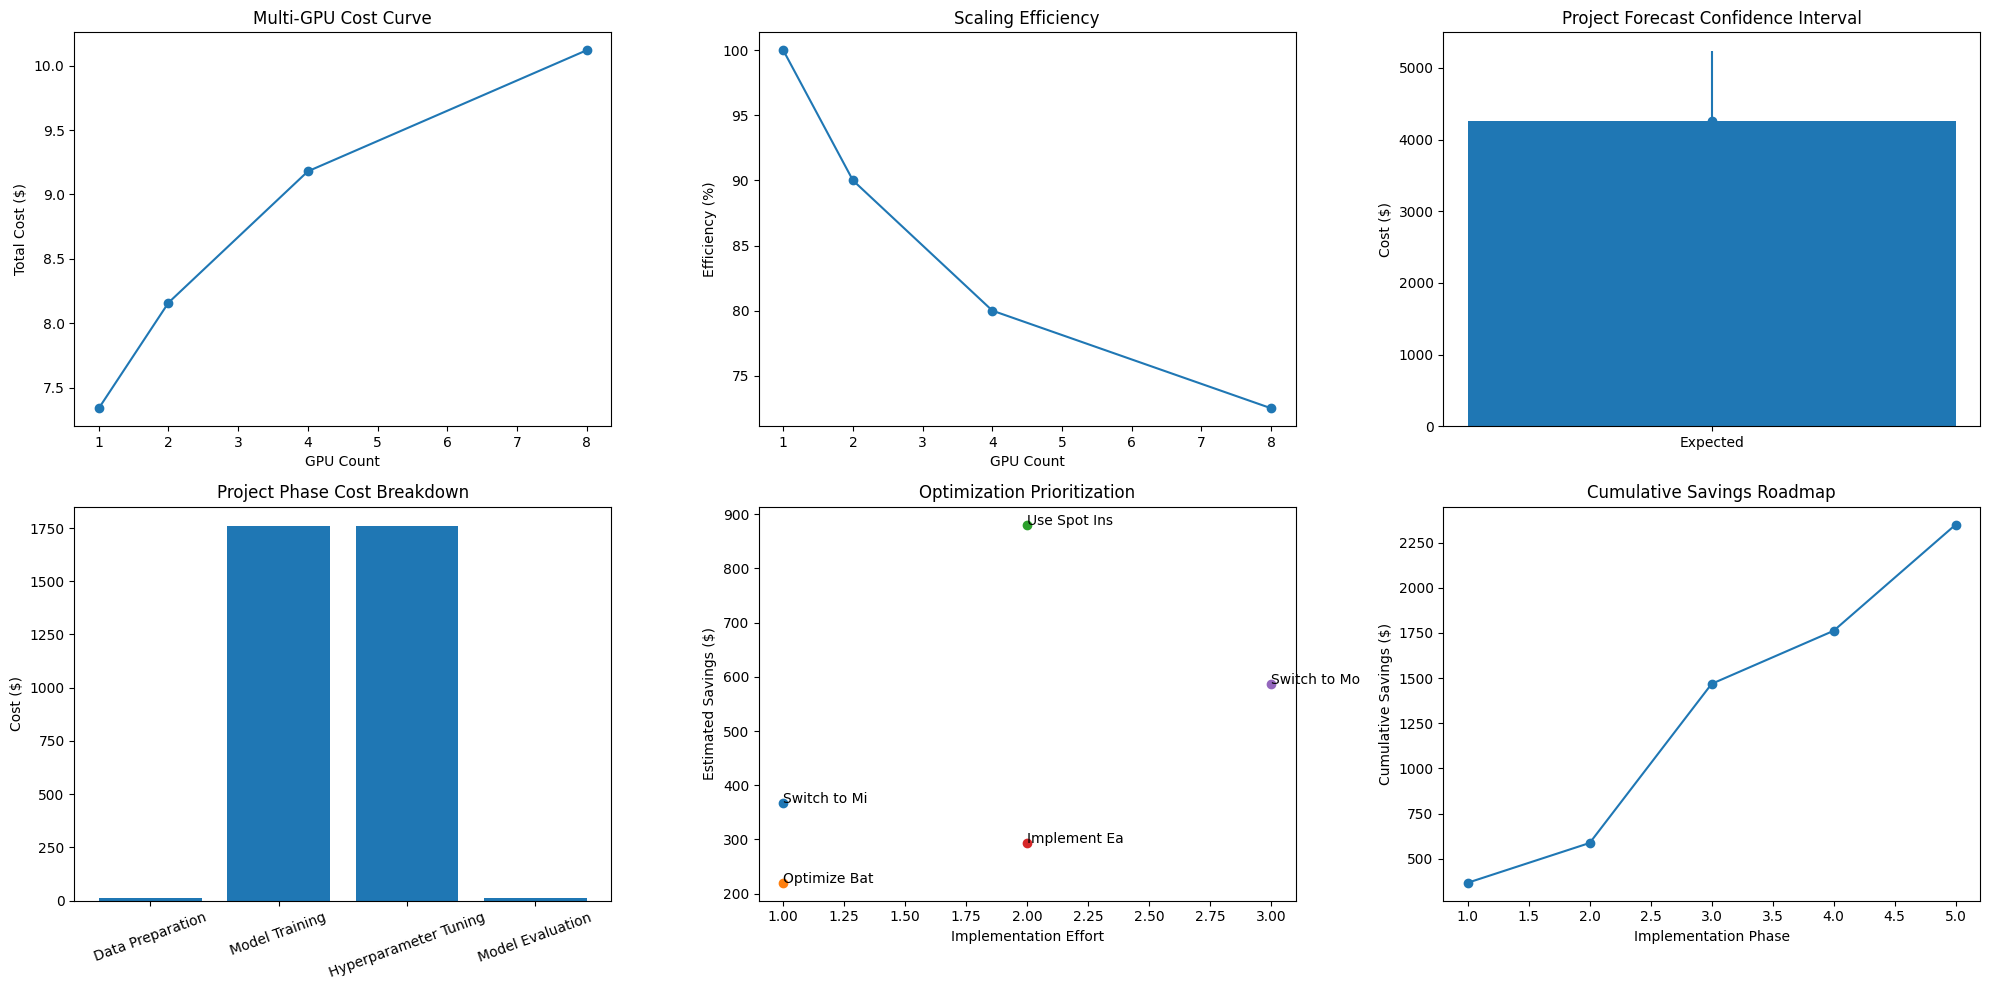

In [40]:
display_student_header()

# Cell 30: Integrated Cost Dashboard
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)

# TODO: Create comprehensive dashboard combining all Part 8.5 analyses
# Hint: Use matplotlib subplots to show multiple visualizations

def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """
    TODO: Implement this function to create an integrated dashboard

    Parameters:
        multi_gpu_analysis (dict): Results from multi-gpu cost analysis
        project_forecast (dict): Results from project cost forecasting
        optimization_recommendations (dict): Results from optimization analysis

    Returns:
        matplotlib figure with comprehensive dashboard
    """
    # TODO: Implement the dashboard visualization
    # - Create figure with multiple subplots (2x3 or 3x2)
    # - Plot 1: Multi-GPU cost curve (GPU count vs total cost)
    # - Plot 2: Scaling efficiency (GPU count vs speedup factor)
    # - Plot 3: Project forecast with confidence intervals
    # - Plot 4: Phase-by-phase cost breakdown
    # - Plot 5: Optimization prioritization (savings vs effort scatter)
    # - Plot 6: Cumulative savings roadmap
    # - Use appropriate colors and labels
    # - Return the figure
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))

    # -------------------------------------------------
    # Plot 1: Multi-GPU Cost Curve
    # -------------------------------------------------
    gpu_counts = [
        r["gpu_count"]
        for r in multi_gpu_analysis
    ]

    gpu_costs = [
        r["total_cost"]
        for r in multi_gpu_analysis
    ]

    axes[0, 0].plot(
        gpu_counts,
        gpu_costs,
        marker="o"
    )

    axes[0, 0].set_title("Multi-GPU Cost Curve")
    axes[0, 0].set_xlabel("GPU Count")
    axes[0, 0].set_ylabel("Total Cost ($)")

    # -------------------------------------------------
    # Plot 2: Scaling Efficiency
    # -------------------------------------------------
    efficiencies = [
        r["efficiency"]
        for r in multi_gpu_analysis
    ]

    axes[0, 1].plot(
        gpu_counts,
        efficiencies,
        marker="o"
    )

    axes[0, 1].set_title("Scaling Efficiency")
    axes[0, 1].set_xlabel("GPU Count")
    axes[0, 1].set_ylabel("Efficiency (%)")

    # -------------------------------------------------
    # Plot 3: Project Forecast Confidence Interval
    # -------------------------------------------------
    expected_cost = project_forecast["expected_total"]

    ci_low, ci_high = project_forecast["confidence_interval"]

    axes[0, 2].bar(
        ["Expected"],
        [expected_cost]
    )

    axes[0, 2].errorbar(
        ["Expected"],
        [expected_cost],
        yerr=[
            [expected_cost - ci_low],
            [ci_high - expected_cost]
        ],
        fmt="o"
    )

    axes[0, 2].set_title("Project Forecast Confidence Interval")
    axes[0, 2].set_ylabel("Cost ($)")

    # -------------------------------------------------
    # Plot 4: Phase-by-Phase Cost Breakdown
    # -------------------------------------------------
    phase_names = [
        p["name"]
        for p in project_forecast["phases"]
    ]

    phase_costs = [
        p["base_cost"]
        for p in project_forecast["phases"]
    ]

    axes[1, 0].bar(
        phase_names,
        phase_costs
    )

    axes[1, 0].set_title("Project Phase Cost Breakdown")
    axes[1, 0].set_ylabel("Cost ($)")
    axes[1, 0].tick_params(axis="x", rotation=20)

    # -------------------------------------------------
    # Plot 5: Optimization Prioritization
    # -------------------------------------------------
    effort_mapping = {
        "LOW": 1,
        "MEDIUM": 2,
        "HIGH": 3
    }

    for strategy in optimization_recommendations[
        "prioritized_recommendations"
    ]:

        effort = effort_mapping[
            strategy["implementation_effort"]
        ]

        savings = strategy["estimated_savings"]

        axes[1, 1].scatter(
            effort,
            savings
        )

        axes[1, 1].text(
            effort,
            savings,
            strategy["name"][:12]
        )

    axes[1, 1].set_title("Optimization Prioritization")
    axes[1, 1].set_xlabel("Implementation Effort")
    axes[1, 1].set_ylabel("Estimated Savings ($)")

    # -------------------------------------------------
    # Plot 6: Cumulative Savings Roadmap
    # -------------------------------------------------
    roadmap_phases = [
        r["phase"]
        for r in optimization_recommendations["roadmap"]
    ]

    cumulative_savings = [
        r["cumulative_savings"]
        for r in optimization_recommendations["roadmap"]
    ]

    axes[1, 2].plot(
        roadmap_phases,
        cumulative_savings,
        marker="o"
    )

    axes[1, 2].set_title("Cumulative Savings Roadmap")
    axes[1, 2].set_xlabel("Implementation Phase")
    axes[1, 2].set_ylabel("Cumulative Savings ($)")

    plt.tight_layout()

    return fig

# TODO: Call the function with your analysis results
# Hint: Use placeholder data if you haven't implemented the functions yet

dashboard_fig = create_advanced_finops_dashboard(
    results,
    forecast,
    analysis
)

plt.savefig("advanced_finops_dashboard.png")

print("\n✅ Dashboard created successfully!")
print("📁 Saved as: advanced_finops_dashboard.png")

plt.show()

In [44]:
display_student_header()

# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

# TODO: Design a comprehensive cost optimization strategy for a given scenario
# This is an open-ended challenge that combines all Part 8.5 concepts

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,  # hours baseline
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,  # USD
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

print("📋 CHALLENGE SCENARIO:")
print(f"   Project: {challenge_scenario['project']}")
print(f"   Baseline: {challenge_scenario['requirements']['gpu_count']}x {challenge_scenario['requirements']['gpu_type']} for {challenge_scenario['requirements']['training_duration']}h")
print(f"   Budget: ${challenge_scenario['requirements']['budget']}")
print(f"   Deadline: {challenge_scenario['constraints']['deadline']}")

# TODO: Your task:
# 1. Calculate baseline cost
# 2. Apply multi-GPU analysis to find optimal GPU count
# 3. Select optimization strategies from Exercise 8.5.3
# 4. Forecast final cost with uncertainty
# 5. Ensure strategy meets budget and constraints
# 6. Present your strategy with justification
gpu_type = challenge_scenario["requirements"]["gpu_type"]
gpu_count = challenge_scenario["requirements"]["gpu_count"]
training_duration = challenge_scenario["requirements"]["training_duration"]

# -------------------------------------------------
# Step 1: Baseline Cost
# -------------------------------------------------
baseline_cost = (
    GPU_PRICING[gpu_type] *
    gpu_count *
    training_duration
)

print("\n📊 Step 1: Baseline Cost")
print(f"Baseline Cost = ${round(baseline_cost, 2)}")

# -------------------------------------------------
# Step 2: Multi-GPU Analysis
# -------------------------------------------------
candidate_gpu_counts = [2, 4, 8]

multi_gpu_results = analyze_multi_gpu_cost(
    base_time_hours=training_duration,
    gpu_type=gpu_type,
    gpu_counts=candidate_gpu_counts
)

optimal_gpu_config = min(
    multi_gpu_results,
    key=lambda x: x["total_cost"]
)

print("\n📊 Step 2: Multi-GPU Analysis")
print(f"Optimal GPU Count: {optimal_gpu_config['gpu_count']}")
print(f"Estimated Cost: ${optimal_gpu_config['total_cost']}")
print(f"Training Time: {optimal_gpu_config['training_time']}h")
print(f"Efficiency: {optimal_gpu_config['efficiency']}%")

# -------------------------------------------------
# Step 3: Select Optimization Strategies
# -------------------------------------------------
selected_strategies = [
    strategy for strategy in example_strategies
    if strategy["risk_level"] != "HIGH"
]

optimization_analysis = analyze_optimization_opportunities(
    current_training_config,
    selected_strategies
)

print("\n📊 Step 3: Selected Optimization Strategies")

for strategy in optimization_analysis[
    "prioritized_recommendations"
]:
    print(
        f"- {strategy['name']} "
        f"(Savings: ${strategy['estimated_savings']})"
    )

# -------------------------------------------------
# Step 4: Calculate Savings
# -------------------------------------------------
total_savings = optimization_analysis[
    "total_possible_savings"
]

optimized_cost = baseline_cost - total_savings

print("\n📊 Step 4: Cumulative Savings")
print(f"Total Potential Savings: ${round(total_savings, 2)}")
print(f"Optimized Cost Estimate: ${round(optimized_cost, 2)}")

# -------------------------------------------------
# Step 5: Forecast with Uncertainty
# -------------------------------------------------
forecast_phases = [
    {
        "name": "LLM Fine-tuning",
        "gpu_type": gpu_type,
        "gpu_count": optimal_gpu_config["gpu_count"],
        "duration_hours": optimal_gpu_config["training_time"],
        "uncertainty_pct": 0.20
    }
]

forecast_result = forecast_project_cost(
    forecast_phases,
    contingency_pct=15
)

ci_low, ci_high = forecast_result["confidence_interval"]

print("\n📊 Step 5: Forecast with Confidence Interval")
print(f"Expected Total Cost: ${forecast_result['expected_total']}")
print(f"Confidence Interval: ${ci_low} - ${ci_high}")

# -------------------------------------------------
# Step 6: Constraint Validation
# -------------------------------------------------
budget_limit = challenge_scenario["requirements"]["budget"]

under_budget = (
    forecast_result["expected_total"] <= budget_limit
)

print("\n📊 Step 6: Constraint Validation")
print(f"Budget Limit: ${budget_limit}")
print(f"Under Budget: {'YES' if under_budget else 'NO'}")

# -------------------------------------------------
# Step 7: Strategy Summary
# -------------------------------------------------
print("\n✅ FINAL OPTIMIZATION STRATEGY")
print("-" * 60)

print(f"Project: {challenge_scenario['project']}")
print(f"Recommended GPU Count: {optimal_gpu_config['gpu_count']}")
print(f"Recommended Precision: Mixed Precision (AMP)")
print(f"Recommended Instance Type: On-Demand")
print(f"Estimated Final Cost: ${forecast_result['expected_total']}")
print(f"Confidence Range: ${ci_low} - ${ci_high}")

print("\n📌 Key Optimizations Applied:")

for strategy in optimization_analysis[
    "prioritized_recommendations"
]:
    print(f"   • {strategy['name']}")

print("\n📌 Justification:")
print("   • Mixed precision reduces compute cost while maintaining accuracy.")
print("   • Batch size optimization improves GPU utilization.")
print("   • Early stopping prevents unnecessary training epochs.")
print("   • High-risk spot instances were avoided due to MEDIUM risk constraint.")
print("   • Configuration balances cost efficiency and project deadline.")

CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
📋 CHALLENGE SCENARIO:
   Project: Large Language Model Fine-tuning
   Baseline: 8x A100 for 200h
   Budget: $5000
   Deadline: 2 weeks

📊 Step 1: Baseline Cost
Baseline Cost = $5872.0

📊 Step 2: Multi-GPU Analysis
Optimal GPU Count: 2
Estimated Cost: $815.56
Training Time: 111.11h
Efficiency: 90.0%

📊 Step 3: Selected Optimization Strategies
- Switch to Mixed Precision (AMP) (Savings: $367.0)
- Optimize Batch Size (Savings: $220.2)
- Implement Early Stopping (Savings: $293.6)
- Switch to More Efficient GPU Type (Savings: $587.2)

📊 Step 4: Cumulative Savings
Total Potential Savings: $1468.0
Optimized Cost Estimate: $4404.0

📊 Step 5: Forecast with Confidence Interval
Expected Total Cost: $937.88
Confidence Interval: $774.77 - $1100.99

📊 Step 6: Constraint Validation
Budget Limit: $5000
Under Budget: YES

✅ FINAL OPTIMIZATION STRATEGY
------------------------------------------------------------
Project: Large Language Model Fi

✅ Saved: multi_gpu_scaling.png


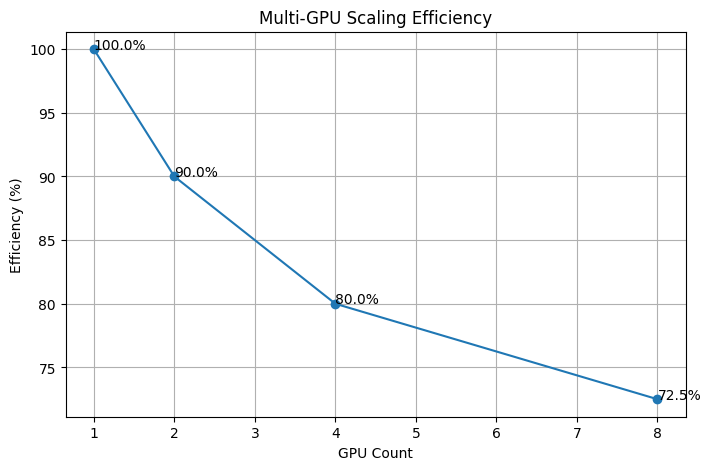

✅ Saved: project_forecast.png


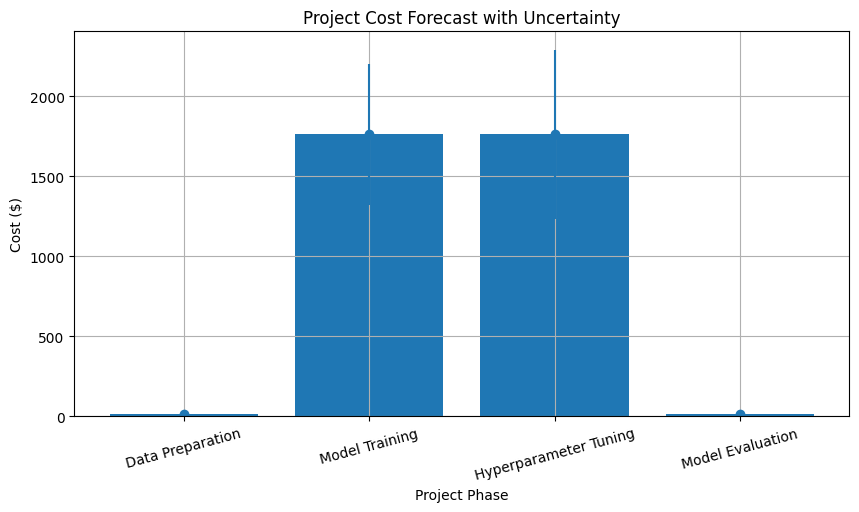

✅ Saved: optimization_roadmap.png


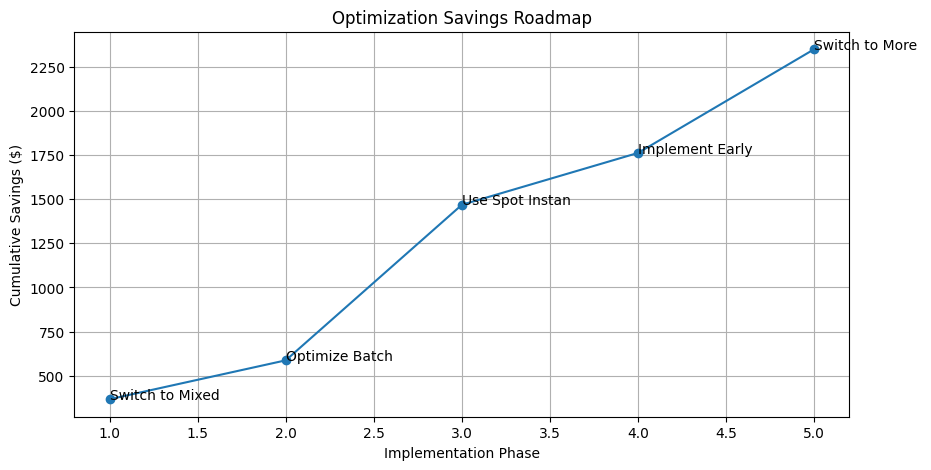

In [46]:
display_student_header()

import matplotlib.pyplot as plt

# =========================================================
# Plot 1: Multi-GPU Scaling Efficiency
# =========================================================

gpu_counts = [r["gpu_count"] for r in results]
efficiencies = [r["efficiency"] for r in results]
costs = [r["total_cost"] for r in results]

plt.figure(figsize=(8, 5))

plt.plot(
    gpu_counts,
    efficiencies,
    marker="o"
)

for i, efficiency in enumerate(efficiencies):
    plt.text(
        gpu_counts[i],
        efficiency,
        f"{efficiency}%"
    )

plt.title("Multi-GPU Scaling Efficiency")
plt.xlabel("GPU Count")
plt.ylabel("Efficiency (%)")
plt.grid(True)

plt.savefig(
    "multi_gpu_scaling.png",
    bbox_inches="tight"
)

print("✅ Saved: multi_gpu_scaling.png")

plt.show()

# =========================================================
# Plot 2: Project Forecast
# =========================================================

phase_names = [
    phase["name"]
    for phase in forecast["phases"]
]

phase_costs = [
    phase["base_cost"]
    for phase in forecast["phases"]
]

best_case = [
    phase["best_case"]
    for phase in forecast["phases"]
]

worst_case = [
    phase["worst_case"]
    for phase in forecast["phases"]
]

plt.figure(figsize=(10, 5))

plt.bar(
    phase_names,
    phase_costs
)

plt.errorbar(
    phase_names,
    phase_costs,
    yerr=[
        [
            phase_costs[i] - best_case[i]
            for i in range(len(phase_costs))
        ],
        [
            worst_case[i] - phase_costs[i]
            for i in range(len(phase_costs))
        ]
    ],
    fmt="o"
)

plt.title("Project Cost Forecast with Uncertainty")
plt.xlabel("Project Phase")
plt.ylabel("Cost ($)")
plt.xticks(rotation=15)
plt.grid(True)

plt.savefig(
    "project_forecast.png",
    bbox_inches="tight"
)

print("✅ Saved: project_forecast.png")

plt.show()

# =========================================================
# Plot 3: Optimization Roadmap
# =========================================================

roadmap_phases = [
    item["phase"]
    for item in analysis["roadmap"]
]

cumulative_savings = [
    item["cumulative_savings"]
    for item in analysis["roadmap"]
]

strategy_names = [
    item["strategy"]
    for item in analysis["roadmap"]
]

plt.figure(figsize=(10, 5))

plt.plot(
    roadmap_phases,
    cumulative_savings,
    marker="o"
)

for i, strategy in enumerate(strategy_names):

    plt.text(
        roadmap_phases[i],
        cumulative_savings[i],
        strategy[:15]
    )

plt.title("Optimization Savings Roadmap")
plt.xlabel("Implementation Phase")
plt.ylabel("Cumulative Savings ($)")
plt.grid(True)

plt.savefig(
    "optimization_roadmap.png",
    bbox_inches="tight"
)

print("✅ Saved: optimization_roadmap.png")

plt.show()

---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway